# Data Quality Report

Variables assigned (J-N):
- unique_reach: number of people exposed to campaign
- unique_engaged_hcps: number of unique healthcare professionals who engaged with campaign
- total_engagements: total interactions with campaigns
- total_budget_spent: total dollars spent on campaign	
- engagement_rate: percent of HCPs who engaged with campaign

In [16]:
import pandas as pd
import numpy as np

df = pd.read_excel("../data/BreakThroughTech_training_data_1.xlsx")
df.head()

feilds_needed = [
    "unique_reach",
    "unique_engaged_hcps",
    "total_engagements",
    "total_budget_spent",
    "engagement_rate"
]

sub_df = df[feilds_needed]
sub_df.head(10)

,unique_reach,unique_engaged_hcps,total_engagements,total_budget_spent,engagement_rate
0,9270,1070,4449,173511.0,0.1154
1,1959,380,1178,45942.0,0.1940
2,2860,403,1703,66417.0,0.1409
3,7390,910,1107,43173.0,0.1231
4,77570,26264,116027,348081.0,0.3386
5,7191,2493,7028,21084.0,0.3467
6,1544,779,2793,8379.0,0.5045
7,69886,6927,27076,1055964.0,0.0991
8,621,124,442,17238.0,0.1997
9,2466,1025,3039,9117.0,0.4157


In [17]:
# Chechk for missing values
missing_values = sub_df.isnull().sum()
print("Missing values in each column:" )
missing_values

Missing values in each column:


unique_reach           0
unique_engaged_hcps    0
total_engagements      0
total_budget_spent     0
engagement_rate        0
dtype: int64

In [18]:
# Check for Data Types
data_types = sub_df.dtypes
print("Data types of each column:")
data_types

Data types of each column:


unique_reach             int64
unique_engaged_hcps      int64
total_engagements        int64
total_budget_spent     float64
engagement_rate        float64
dtype: object

In [19]:
# Check for Duplicates
duplicate_rows = sub_df[sub_df.duplicated()]
print("Number of duplicate rows:", len(duplicate_rows))

Number of duplicate rows: 0


## Seems like there are no obvious data quality issues with the data
None of the following in the feature given:
- Missing Values
- Bad DataTypes that may need processing (all are ints or floats)
- Duplicate rows

In [20]:
# Check for 0s in the data
zero_values = (sub_df == 0).sum()
print("Number of 0s in each column:")
zero_values

Number of 0s in each column:


unique_reach           0
unique_engaged_hcps    0
total_engagements      0
total_budget_spent     2
engagement_rate        0
dtype: int64

In [ ]:
# Checking for strange values in the data
rows_with_zeros = sub_df[(sub_df == 0).any(axis=1)]
print(rows_with_zeros)
df.loc[rows_with_zeros.index, "brand"]



     unique_reach  unique_engaged_hcps  total_engagements  total_budget_spent  \
146          1460                  408                643                 0.0   
173           984                  268                595                 0.0   

     engagement_rate  
146           0.2795  
173           0.2724  


146    JANSSEN BIOTECH
173              LILLY
Name: brand, dtype: str

Companies Janssen BioTech and Lilly have 0.0 budget spend but have total_engagements in the hundreds and unique_reach values as well. This may need to be investigated if these are true values for campaign data.

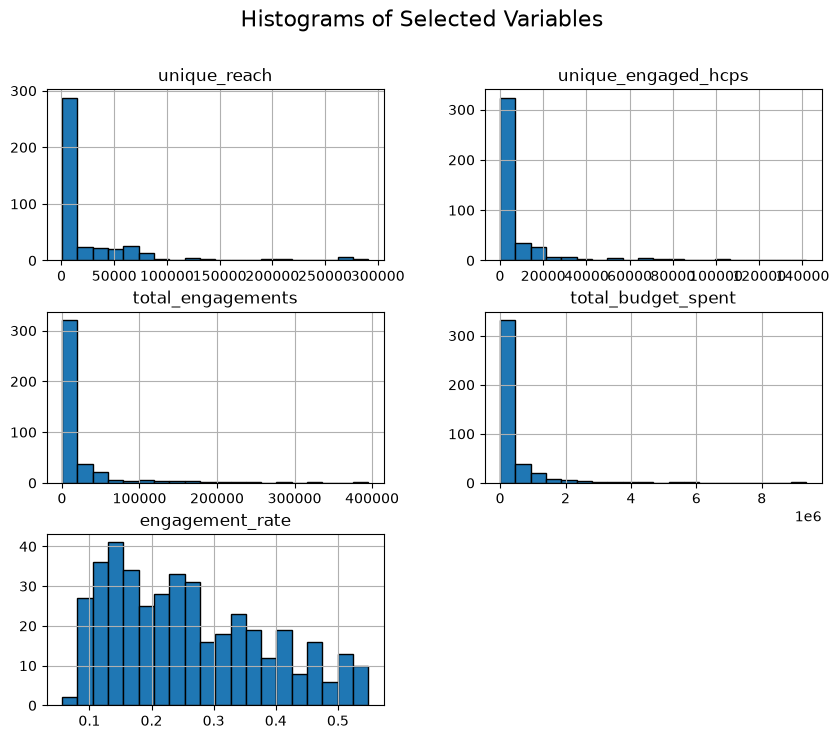

In [22]:
import matplotlib.pyplot as plt

sub_df.hist(
    figsize=(10, 8),
    bins=20,
    edgecolor='black'
)

plt.suptitle("Histograms of Selected Variables", fontsize=16)
plt.show()

## A much bigger issue: total_engagements, total_budget_spent, unique_engaged_hcps, and unique_reach are extremly right skewed which might affect the model's performance. These may need to be adjusted using log

## Summary Table — Data Quality Findings for J–N

| Column | Issue | Rows affected | Percentage | Proposed fix |
|---|---|---:|---:|---|
| total_budget_spent | Two zero values despite positive reach and engagements | 2 | 0.5% | Review the records; do not impute until zero spend is confirmed as valid |
| engagement_rate | Derived from unique_engaged_hcps / unique_reach and rounded to four decimals | 417 | 100.0% | Recompute from the numerator and denominator, or document the rounding |
| Numeric features | Strong right-skew in reach, engaged HCPs, engagements, and budget | 417 | 100.0% | Consider log1p transformation for linear models; inspect outliers before removing rows |